In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import math

In [2]:
df = pd.read_csv('../data/data_clean.csv')
print("Data loaded successfully")

Data loaded successfully


In [3]:
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [4]:
df.tail()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
995,3261,4,1,1978,2.165110,2,10,701493.997069
996,3179,1,2,1999,2.977123,1,10,683723.160704
997,2606,4,2,1962,4.055067,0,2,572024.023634
998,4723,5,2,1950,1.930921,0,7,964865.298639
999,3268,4,2,1983,3.108790,2,2,742599.253332


In [5]:
df.columns

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [7]:
df_cont = df[['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
        'Garage_Size', 'Neighborhood_Quality']]

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kurtosis

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns

sns.set(style="whitegrid")

# Load dataset and get numerical features
df = pd.read_csv('../data/house_price.csv')
df_cont = df.select_dtypes(include=[np.number])

summary_list = []
for col in df_cont.columns:
    data = df[col].dropna()

    if data.empty:
        summary_list.append({
            'Feature': col, 'Min': np.nan, 'Max': np.nan, 'Range': np.nan,
            'Mean': np.nan, 'Median': np.nan, 'Mode_rel': np.nan, 'Std Dev': np.nan,
            'Variance': np.nan, 'Skewness': np.nan, 'Skewness Direction': 'No data',
            'Kurtosis': np.nan, 'Q1': np.nan, 'Q2': np.nan, 'Q3': np.nan,
            'Lower Whisker Point': np.nan, 'Upper Whisker Point': np.nan,
            'Below LWP Count': 0, 'Above UWP Count': 0, 'Total Outliers': 0,
            'Any Zero?': False, 'Any Positive?': False, 'Any Negative?': False
        })
        continue

    mini = data.min()
    maxi = data.max()
    rangi = maxi - mini
    mean = data.mean()
    median = data.median()
    mode_formula = round(3 * median - 2 * mean, 3)
    std_dev = data.std(ddof=1)
    variance = data.var(ddof=1)
    skewness = data.skew()
    
    if pd.isna(skewness) or abs(skewness) < 1e-12:
        skew_dir = "No skewness"
    elif skewness < 0:
        skew_dir = "Left skewed"
    else:
        skew_dir = "Right skewed"

    kurt = data.kurtosis()
    q1 = data.quantile(0.25)
    q2 = data.quantile(0.50)
    q3 = data.quantile(0.75)

    iqr = q3 - q1
    lwp = q1 - 1.5 * iqr
    uwp = q3 + 1.5 * iqr
    below_lwp = int((data < lwp).sum())
    above_uwp = int((data > uwp).sum())
    total_outliers = below_lwp + above_uwp

    any_zero = (data == 0).any()
    any_positive = (data > 0).any()
    any_negative = (data < 0).any()

    summary_list.append({
        'Feature': col,
        'Min': round(mini, 6) if pd.notna(mini) else np.nan,
        'Max': round(maxi, 6) if pd.notna(maxi) else np.nan,
        'Range': round(rangi, 6) if pd.notna(rangi) else np.nan,
        'Mean': round(mean, 6) if pd.notna(mean) else np.nan,
        'Median': round(median, 6) if pd.notna(median) else np.nan,
        'Mode_rel': mode_formula,
        'Std Dev': round(std_dev, 6) if pd.notna(std_dev) else np.nan,
        'Variance': round(variance, 6) if pd.notna(variance) else np.nan,
        'Skewness': round(skewness, 6) if pd.notna(skewness) else np.nan,
        'Skewness Direction': skew_dir,
        'Kurtosis': round(kurt, 6) if pd.notna(kurt) else np.nan,
        'Q1': round(q1, 6) if pd.notna(q1) else np.nan,
        'Q2': round(q2, 6) if pd.notna(q2) else np.nan,
        'Q3': round(q3, 6) if pd.notna(q3) else np.nan,
        'Lower Whisker Point': round(lwp, 6) if pd.notna(lwp) else np.nan,
        'Upper Whisker Point': round(uwp, 6) if pd.notna(uwp) else np.nan,
        'Below LWP Count': below_lwp,
        'Above UWP Count': above_uwp,
        'Total Outliers': total_outliers,
        'Any Zero?': any_zero,
        'Any Positive?': any_positive,
        'Any Negative?': any_negative
    })

distribution_summary = pd.DataFrame(summary_list)
pd.set_option('display.max_columns', None)
display(distribution_summary)

,Feature,Min,Max,Range,Mean,Median,Mode_rel,Std Dev,Variance,Skewness,Skewness Direction,Kurtosis,Q1,Q2,Q3,Lower Whisker Point,Upper Whisker Point,Below LWP Count,Above UWP Count,Total Outliers,Any Zero?,Any Positive?,Any Negative?
0,Square_Footage,503.000000,4.999000e+03,4496.000000,2815.422000,2862.500000,2956.656,1255.514921,1.576318e+06,-0.066001,Left skewed,-1.128061,1749.500000,2862.500000,3849.500000,-1400.500000,6.999500e+03,0,0,0,False,True,False
1,Num_Bedrooms,1.000000,5.000000e+00,4.000000,2.990000,3.000000,3.020,1.427564,2.037938e+00,0.025884,Right skewed,-1.333604,2.000000,3.000000,4.000000,-1.000000,7.000000e+00,0,0,0,False,True,False
2,Num_Bathrooms,1.000000,3.000000e+00,2.000000,1.973000,2.000000,2.054,0.820332,6.729440e-01,0.049917,Right skewed,-1.512391,1.000000,2.000000,3.000000,-2.000000,6.000000e+00,0,0,0,False,True,False
3,Year_Built,1950.000000,2.022000e+03,72.000000,1986.550000,1986.000000,1984.900,20.632916,4.257172e+02,-0.021254,Left skewed,-1.185454,1969.000000,1986.000000,2004.250000,1916.125000,2.057125e+03,0,0,0,False,True,False
4,Lot_Size,0.506058,4.989303e+00,4.483244,2.778087,2.809740,2.873,1.297903,1.684553e+00,-0.044288,Left skewed,-1.200895,1.665946,2.809740,3.923317,-1.720112,7.309375e+00,0,0,0,False,True,False
5,Garage_Size,0.000000,2.000000e+00,2.000000,1.022000,1.000000,0.956,0.814973,6.641800e-01,-0.040400,Left skewed,-1.493259,0.000000,1.000000,2.000000,-3.000000,5.000000e+00,0,0,0,True,True,False
6,Neighborhood_Quality,1.000000,1.000000e+01,9.000000,5.615000,6.000000,6.770,2.887059,8.335110e+00,-0.020445,Left skewed,-1.205551,3.000000,6.000000,8.000000,-4.500000,1.550000e+01,0,0,0,False,True,False
7,House_Price,111626.853424,1.108237e+06,996609.982868,618861.018647,628267.291129,647079.836,253568.058375,6.429676e+10,-0.063955,Left skewed,-1.091382,401648.228909,628267.291129,827141.277637,-236591.344182,1.465381e+06,0,0,0,False,True,False


In [10]:
sns.set(style="whitegrid")

for col in df_cont.columns:
    data = df[col].dropna()
    print(f"\n======================== {col} ========================\n")


======================== Square_Footage ========================


======================== Num_Bedrooms ========================


======================== Num_Bathrooms ========================


======================== Year_Built ========================


======================== Lot_Size ========================


======================== Garage_Size ========================


======================== Neighborhood_Quality ========================


======================== House_Price ========================



In [11]:
if data.empty:
    fig = plt.figure(figsize=(12, 2))
    plt.text(0.5, 0.5, f"No data available for {col}", ha='center', va='center')
    plt.axis('off')
    plt.show()
else:
    print("Data is loaded perfectly and ready for plotting!")

Data is loaded perfectly and ready for plotting!


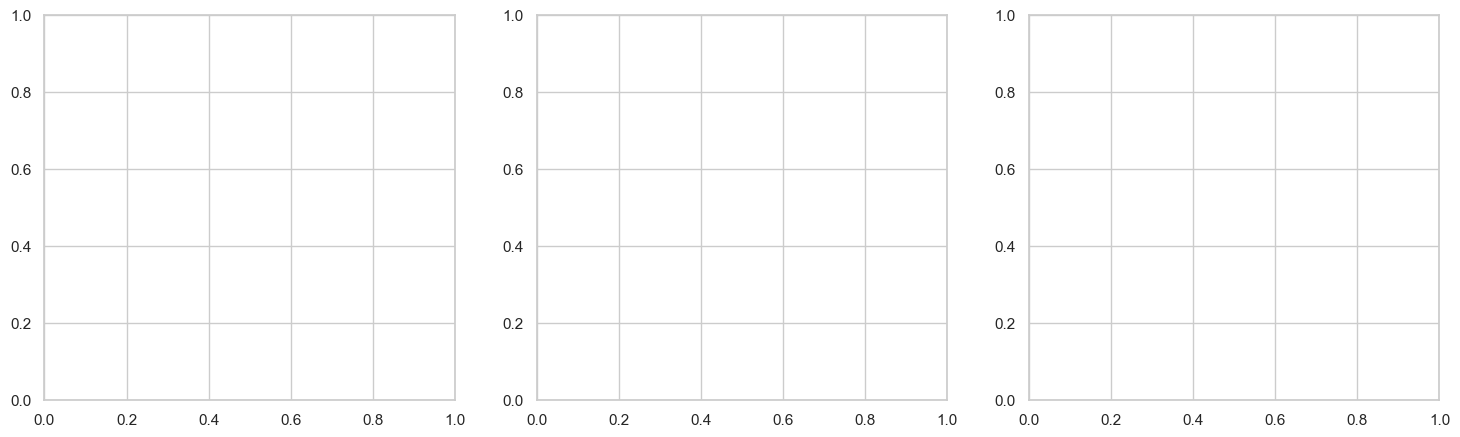

In [12]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

In [14]:
    # LEFT: KDE + Rug
    ax0 = axes[0]
    sns.kdeplot(data, fill=True, ax=ax0)
    sns.rugplot(data, height=0.04, ax=ax0)
    ax0.set_title(f"KDE + Rug for {col}")
    ax0.set_xlabel(col)
    ax0.set_ylabel("Density")

Text(4.444444444444459, 0.5, 'Density')

In [16]:
    ax1 = axes[1]
    sns.histplot(data, kde=True, bins=20, ax=ax1)
    ax1.set_title(f"KDE + Histogram for {col}")
    ax1.set_xlabel(col)
    ax1.set_ylabel("Frequency")

Text(496.79738562091507, 0.5, 'Frequency')

In [18]:
    # RIGHT: Boxplot (vertical)
    ax2 = axes[2]
    sns.boxplot(x=data, ax=ax2, orient='h')
    ax2.set_title(f"Boxplot for {col}\n(LWP & UWP shown by whiskers)")
    ax2.set_xlabel(col)

Text(0.5, 4.444444444444445, 'House_Price')

In [20]:
    # annotate LWP & UWP and outlier counts on the boxplot
    # retrieve values computed earlier from distribution_summary
    row = distribution_summary[distribution_summary['Feature'] == col].iloc[0]
    lwp = row['Lower Whisker Point']
    uwp = row['Upper Whisker Point']
    below_lwp = int(row['Below LWP Count'])
    above_uwp = int(row['Above UWP Count'])
    total_outliers = int(row['Total Outliers'])

In [23]:
    if pd.notna(lwp):
        ax2.axvline(lwp, color='red', linestyle='--', label='LWP')
    if pd.notna(uwp):
        ax2.axvline(uwp, color='red', linestyle='--', label='UWP')

In [25]:
    text_y = 0.6  # relative y position for the text (works for horizontal boxplot)
    ax2.text(0.02, text_y, f"Below LWP: {below_lwp}", transform=ax2.transAxes, fontsize=9)
    ax2.text(0.02, text_y - 0.12, f"Above UWP: {above_uwp}", transform=ax2.transAxes, fontsize=9)
    ax2.text(0.02, text_y - 0.24, f"Total Outliers: {total_outliers}", transform=ax2.transAxes, fontsize=9)
    ax2.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

<Figure size 640x480 with 0 Axes>

In [26]:
missing_summary = pd.DataFrame({
    'Feature': df.columns,
    'Any Null?': df.isnull().any().values,
    'Null Count': df.isnull().sum().values,
    'Null Percentage (%)': (df.isnull().sum().values / len(df)) * 100,
    'Non-Null Count': df.notnull().sum().values,
    'Non-Null Percentage (%)': (df.notnull().sum().values / len(df)) * 100
})

display(missing_summary)

,Feature,Any Null?,Null Count,Null Percentage (%),Non-Null Count,Non-Null Percentage (%)
0,Square_Footage,False,0,0.0,1000,100.0
1,Num_Bedrooms,False,0,0.0,1000,100.0
2,Num_Bathrooms,False,0,0.0,1000,100.0
3,Year_Built,False,0,0.0,1000,100.0
4,Lot_Size,False,0,0.0,1000,100.0
5,Garage_Size,False,0,0.0,1000,100.0
6,Neighborhood_Quality,False,0,0.0,1000,100.0
7,House_Price,False,0,0.0,1000,100.0


In [27]:
# Display null records (with condition)
null_rows = df[df.isnull().any(axis=1)]

print("\nNull Records:")
if null_rows.shape[0] > 0:
    display(null_rows)
else:
    print("No Null Values Found in the Dataset")

df.columns


Null Records:
No Null Values Found in the Dataset


Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='object')

In [29]:
df_corr = df.select_dtypes(include=[np.number])
pearson = df_corr.corr(method='pearson')
spearman = df_corr.corr(method='spearman')

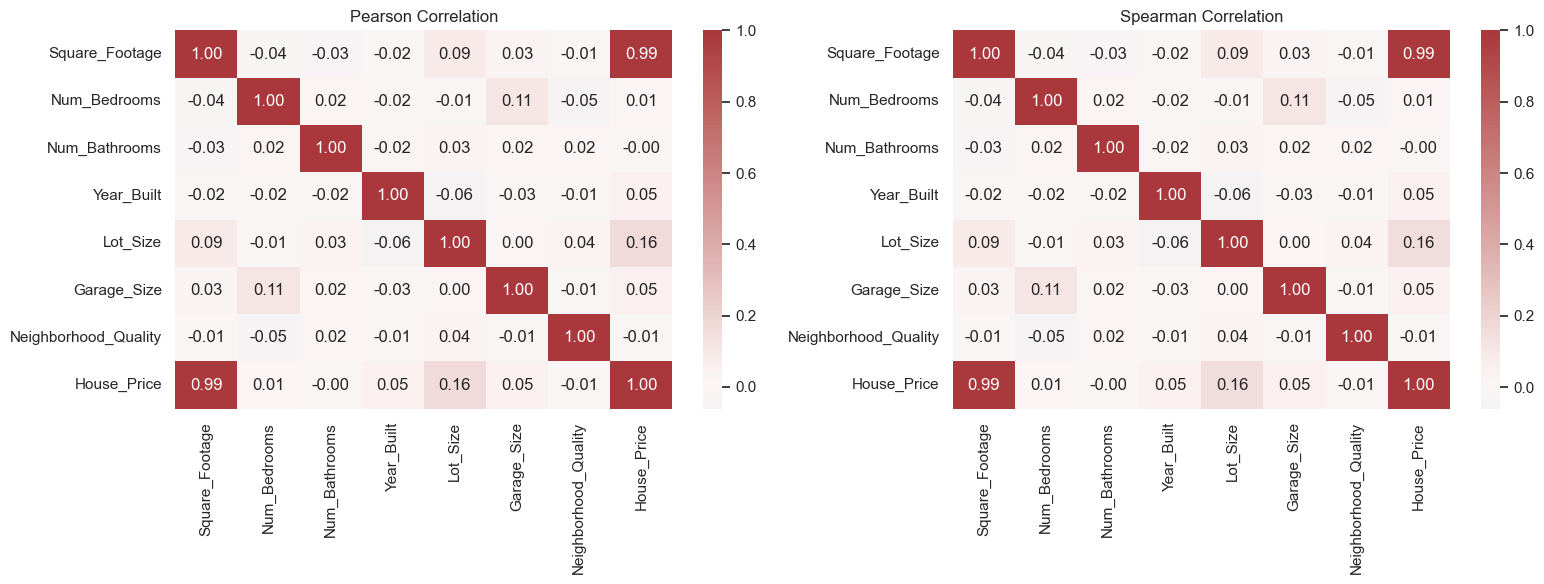

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(pearson, annot=True, fmt=".2f", cmap='vlag', center=0, ax=axes[0])
axes[0].set_title("Pearson Correlation")

sns.heatmap(spearman, annot=True, fmt=".2f", cmap='vlag', center=0, ax=axes[1])
axes[1].set_title("Spearman Correlation")

plt.tight_layout()
plt.show()

In [31]:
X = df[['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality']]
y = df['House_Price']

In [32]:
from sklearn.model_selection import train_test_split
import pandas as pd

# -------------------------------
# USER SETTINGS
# -------------------------------
test_size = 0.15       # 15% test
val_size = 0.05        # 5% validation
random_state = 24

In [33]:
# 1) Split into Train + Temp (Test + Val) — STRATIFIED
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=test_size + val_size,
    random_state=random_state
)

# 2) Split Temp into Validation + Test — STRATIFIED
val_ratio = val_size / (test_size + val_size)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=1 - val_ratio,
    random_state=random_state
)

In [34]:
X_train.to_csv("../data/X_train.csv", index=False)
y_train.to_csv("../data/y_train.csv", index=False)

X_val.to_csv("../data/X_val.csv", index=False)
y_val.to_csv("../data/y_val.csv", index=False)

X_test.to_csv("../data/X_test.csv", index=False)
y_test.to_csv("../data/y_test.csv", index=False)

print("Train/Val/Test split completed!\n")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}, y_test: {y_test.shape}")

print("\nFiles saved as:\n"
      "X_train.csv, y_train.csv\n"
      "X_val.csv, y_val.csv\n"
      "X_test.csv, y_test.csv")

Train/Val/Test split completed!

X_train: (800, 7), y_train: (800,)
X_val:   (50, 7), y_val:   (50,)
X_test:  (150, 7), y_test: (150,)

Files saved as:
X_train.csv, y_train.csv
X_val.csv, y_val.csv
X_test.csv, y_test.csv
